In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

In [9]:
data = yf.download('XRP-USD', start='2017-01-01', end='2026-04-28')

[*********************100%***********************]  1 of 1 completed


In [11]:
data = pd.DataFrame(data)

In [13]:
data

Price,Close,High,Low,Open,Volume
Ticker,XRP-USD,XRP-USD,XRP-USD,XRP-USD,XRP-USD
Date,,,,,
2017-11-09,0.217488,0.221791,0.214866,0.217911,147916992
2017-11-10,0.206483,0.219068,0.205260,0.218256,141032992
2017-11-11,0.210430,0.214456,0.205459,0.205948,134503008
2017-11-12,0.197339,0.210214,0.195389,0.210214,251175008
2017-11-13,0.203442,0.204081,0.197456,0.197472,132567000
...,...,...,...,...,...
2026-04-23,1.439062,1.440166,1.410307,1.430030,2601265527
2026-04-24,1.433676,1.448798,1.425052,1.439060,2163141988


In [15]:
len(data)

3092

In [17]:
data.reset_index(inplace= True)

In [19]:
data.drop(columns = ['Date','Open','High','Low','Volume'],inplace = True)

C:\Users\Laraib\AppData\Local\Temp\ipykernel_16184\2051505622.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  data.drop(columns = ['Date','Open','High','Low','Volume'],inplace = True)


In [21]:
data

Price,Close
Ticker,XRP-USD
0,0.217488
1,0.206483
2,0.210430
3,0.197339
4,0.203442
...,...
3087,1.439062
3088,1.433676
3089,1.424219


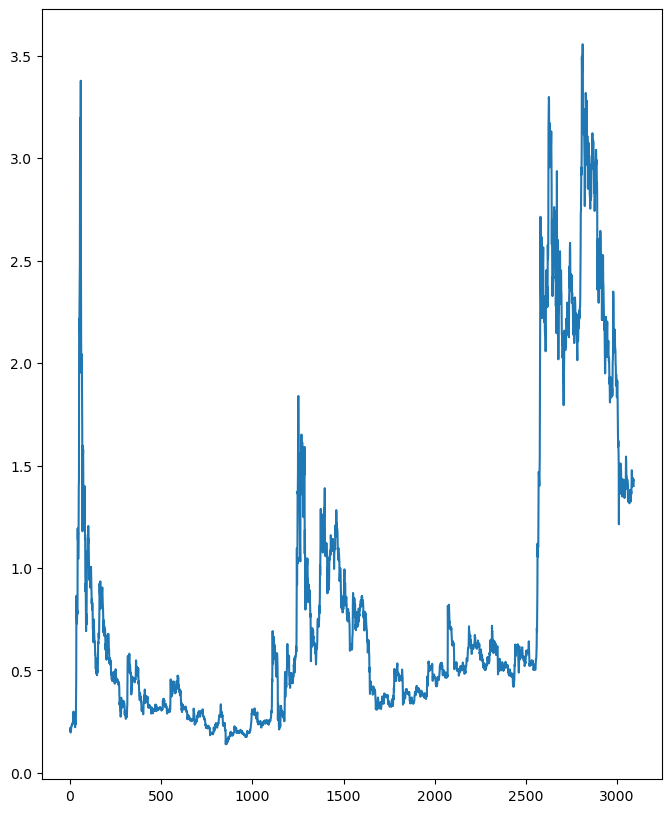

In [23]:
plt.figure(figsize=(8,10))
plt.plot(data)
plt.show()

In [25]:
train_data = data[:-100]
test_data = data[-100:]

In [27]:
train_data.shape

(2992, 1)

In [29]:
test_data.shape

(100, 1)

In [31]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0,1))

In [32]:
train_data_scale = scaler.fit_transform(train_data)

In [33]:
base_days = 100

In [37]:
x = []
y = []
for i in range(base_days, train_data_scale.shape[0]):
    x.append(train_data_scale[i-base_days:i])
    y.append(train_data_scale[i,0])

In [39]:
x[0]

array([[0.02278983],
       [0.01956835],
       [0.02072374],
       [0.01689163],
       [0.01867816],
       [0.02054664],
       [0.02146318],
       [0.02560559],
       [0.02545161],
       [0.02605053],
       [0.02674986],
       [0.02901646],
       [0.02740997],
       [0.02904573],
       [0.03008287],
       [0.03073859],
       [0.03300753],
       [0.03196102],
       [0.03345657],
       [0.04669524],
       [0.03027666],
       [0.03256405],
       [0.03397529],
       [0.0339147 ],
       [0.03305583],
       [0.03335236],
       [0.03116568],
       [0.02719715],
       [0.02435153],
       [0.03292908],
       [0.03075791],
       [0.02859903],
       [0.03280204],
       [0.06847105],
       [0.09701856],
       [0.21211957],
       [0.18048084],
       [0.18120125],
       [0.17233859],
       [0.18698703],
       [0.19074861],
       [0.1862719 ],
       [0.30836797],
       [0.29233228],
       [0.30288807],
       [0.26471914],
       [0.28766033],
       [0.307

In [41]:
x,y = np.array(x), np.array(y)

In [43]:
x = np.reshape(x, (x.shape[0], x.shape[1],1))

In [45]:
from keras.layers import LSTM, Dense, Dropout
from keras.models import Sequential

In [47]:
model = Sequential()
model.add(LSTM(50, activation='relu', return_sequences=True, input_shape =(x.shape[1],1)))
model.add(Dropout(0.2))
model.add(LSTM(60,activation= 'relu', return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(80,activation='relu', return_sequences=True))
model.add(Dropout(0.4))
model.add(LSTM(120,activation= 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1))

C:\Users\Laraib\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [49]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100, 60)             │          26,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100, 60)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 100, 80)             │          45,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100, 80)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 120)                 │          96,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 120)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             121 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [53]:
early_stop = EarlyStopping(
    monitor='loss',          
    patience=5,              
    restore_best_weights=True
)

In [55]:
model.fit(x, y, epochs=50, verbose=1, callbacks=[early_stop])

Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 29s 192ms/step - loss: 0.0387
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 18s 197ms/step - loss: 0.0050
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 18s 192ms/step - loss: 0.0047
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 17s 191ms/step - loss: 0.0045
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 18s 197ms/step - loss: 0.0037
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 17s 191ms/step - loss: 0.0047
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 14s 158ms/step - loss: 0.0034
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 17s 192ms/step - loss: 0.0042
Epoch 9/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 22s 210ms/step - loss: 0.0036
Epoch 10/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 18s 186ms/step - loss: 0.0034
Epoch 11/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 18s 195ms/step - loss: 0.0033
Epoch 12/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 18s 197ms/step - loss: 0.0031
Epoch 13/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 18s 165ms/step - loss: 0.0031
Epoch 14/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 14s 154ms/step - loss: 0.0037
Epoch 15/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 14s 

In [57]:
test_data

Price,Close
Ticker,XRP-USD
2992,1.992658
2993,1.986381
2994,1.889582
2995,1.945558
2996,1.921674
...,...
3087,1.439062
3088,1.433676
3089,1.424219


In [59]:
test_data = pd.concat((train_data.tail(100), test_data),ignore_index=True)

In [61]:
test_data

Price,Close
Ticker,XRP-USD
0,2.358597
1,2.385982
2,2.534958
3,2.606500
4,2.505660
...,...
195,1.439062
196,1.433676
197,1.424219


In [63]:
test_data_scale= scaler.transform(test_data)

In [65]:
x = []
y = []
for i in range(base_days, test_data_scale.shape[0]):
    x.append(test_data_scale[i-base_days:i])
    y.append(test_data_scale[i,0])

In [67]:
x,y = np.array(x), np.array(y)

In [69]:
x = np.reshape(x, (x.shape[0], x.shape[1],1))

In [71]:
pred = model.predict(x)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 247ms/step


In [72]:
pred = scaler.inverse_transform(pred)

In [73]:
pred

array([[2.0397894],
       [2.0356202],
       [2.023476 ],
       [1.9995639],
       [1.9707757],
       [1.9424917],
       [1.9188848],
       [1.9018686],
       [1.8858734],
       [1.8738902],
       [1.8686672],
       [1.8699459],
       [1.8677481],
       [1.8530477],
       [1.8208487],
       [1.7727641],
       [1.7171003],
       [1.6603717],
       [1.6052476],
       [1.5417018],
       [1.4775965],
       [1.420499 ],
       [1.3767917],
       [1.3501959],
       [1.3378553],
       [1.3329618],
       [1.3297871],
       [1.3283414],
       [1.3360105],
       [1.3526896],
       [1.3749785],
       [1.397059 ],
       [1.410629 ],
       [1.4116708],
       [1.4027332],
       [1.3883839],
       [1.370411 ],
       [1.3482993],
       [1.3232906],
       [1.3036155],
       [1.292314 ],
       [1.2861469],
       [1.2833539],
       [1.2810589],
       [1.280386 ],
       [1.2801435],
       [1.2840326],
       [1.2916319],
       [1.2983322],
       [1.3006182],


In [77]:
m = y
z = []

future_days = 30

for i in range(base_days, len(m) + future_days):
    m = m.reshape(-1, 1)

    inter = m[-base_days:]   # ✅ FIX: use m instead of inter
    inter = np.array([inter])
    inter = inter.reshape(inter.shape[0], inter.shape[1], 1)

    pred = model.predict(inter)
    m= np.append(m,pred)
    z = np.append(z, pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━

In [79]:
z = np.array(z)
z = scaler.inverse_transform(z.reshape(-1,1))

In [81]:
z

array([[1.34124592],
       [1.33159141],
       [1.31484919],
       [1.29220879],
       [1.26568775],
       [1.23694464],
       [1.2069673 ],
       [1.1762497 ],
       [1.14516988],
       [1.11388247],
       [1.08247451],
       [1.05105566],
       [1.01974616],
       [0.98871963],
       [0.95802352],
       [0.92769738],
       [0.89774809],
       [0.8681057 ],
       [0.83880356],
       [0.80992728],
       [0.78157694],
       [0.75390892],
       [0.72691254],
       [0.70061181],
       [0.67507353],
       [0.65009184],
       [0.62611948],
       [0.60342557],
       [0.58250385],
       [0.56315839]])

In [83]:
model.save("Ripple_Price_Prediction_Model.keras")